<a href="https://colab.research.google.com/github/zishaan1911/monte-carlo-engine/blob/main/sp500_basket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# Cell 1: Imports
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from numba import njit, prange
from abc import ABC, abstractmethod
from typing import Dict, Optional
import yfinance as yf
import datetime

plt.style.use('ggplot')
print("Cell 1: Dependencies loaded.")

Cell 1: Dependencies loaded.


In [15]:
# Cell 2: Base Interfaces
class MarketData(ABC):
    @abstractmethod
    def get_value(self, time: float) -> float: pass

class Instrument(ABC):
    def __init__(self, maturity: float):
        self.maturity = maturity

    @abstractmethod
    def payoff(self, paths: np.ndarray) -> np.ndarray:
        """paths shape: (n_sims, n_assets, n_steps + 1)"""
        pass

class RandomGenerator(ABC):
    @abstractmethod
    def generate(self, n_sims: int, n_assets: int, n_steps: int) -> np.ndarray: pass

print("Cell 2: Base interfaces defined.")

Cell 2: Base interfaces defined.


In [32]:
# Cell 3: Market Data Calibration & RNG (Updated for Large Baskets)
class ConstantRate(MarketData):
    def __init__(self, rate: float): self.rate = rate
    def get_value(self, time: float) -> float: return self.rate

class MarketCalibrator:
    @staticmethod
    def calibrate(tickers: list, start_date: str, end_date: str):
        print(f"Fetching data for {len(tickers)} tickers...")

        data = yf.download(tickers, start=start_date, end=end_date)['Close']

        data = data.ffill().bfill()

        log_returns = np.log(data / data.shift(1)).dropna()

        vols = log_returns.std().values * np.sqrt(252)
        corr_matrix = log_returns.corr().values
        last_prices = data.iloc[-1].values

        # Small numerical errors can break Cholesky, so we clip eigenvalues
        vals, vecs = np.linalg.eigh(corr_matrix)
        vals = np.maximum(vals, 1e-8)
        corr_matrix = vecs @ np.diag(vals) @ vecs.T

        return last_prices, vols, corr_matrix

class AntitheticMultiRNG(RandomGenerator):
    def generate(self, n_sims: int, n_assets: int, n_steps: int) -> np.ndarray:
        half_sims = n_sims // 2
        z = np.random.standard_normal((half_sims, n_assets, n_steps))
        return np.concatenate([z, -z], axis=0)

print("Cell 3: Large-basket calibrator and RNG ready.")

Cell 3: Large-basket calibrator and RNG ready.


In [33]:
# Cell 4: Unified SDE and Engine
@njit(parallel=True, fastmath=True)
def generate_correlated_paths(S0: np.ndarray, r: float, sigmas: np.ndarray,
                              L: np.ndarray, T: float, n_sims: int,
                              n_steps: int, z: np.ndarray) -> np.ndarray:
    n_assets = S0.shape[0]
    dt = T / n_steps
    sqdt = np.sqrt(dt)

    paths = np.zeros((n_sims, n_assets, n_steps + 1))
    for a in range(n_assets):
        paths[:, a, 0] = S0[a]

    for i in prange(n_sims):
        for j in range(n_steps):
            epsilon = z[i, :, j]
            # Correlate shocks
            corr_epsilon = np.zeros(n_assets)
            for row in range(n_assets):
                for col in range(row + 1):
                    corr_epsilon[row] += L[row, col] * epsilon[col]

            # Geometric Brownian Motion update
            for a in range(n_assets):
                drift = (r - 0.5 * sigmas[a]**2) * dt
                diffusion = sigmas[a] * sqdt * corr_epsilon[a]
                paths[i, a, j+1] = paths[i, a, j] * np.exp(drift + diffusion)

    return paths

class UnifiedMonteCarloEngine:
    def __init__(self, rate_data: MarketData, rng: RandomGenerator):
        self.rate_data = rate_data
        self.rng = rng

    def price(self, instrument: Instrument, S0: np.ndarray, sigmas: np.ndarray,
              corr_matrix: np.ndarray, n_sims: int, n_steps: int,
              z_fixed: Optional[np.ndarray] = None) -> Dict[str, float]:

        n_assets = S0.shape[0]
        r = self.rate_data.get_value(0)
        L = np.linalg.cholesky(corr_matrix)

        # Use provided Z (for Common Random Numbers) or generate new ones
        z = z_fixed if z_fixed is not None else self.rng.generate(n_sims, n_assets, n_steps)

        paths = generate_correlated_paths(S0, r, sigmas, L, instrument.maturity, n_sims, n_steps, z)
        payoffs = instrument.payoff(paths)

        discount = np.exp(-r * instrument.maturity)
        price = discount * np.mean(payoffs)
        std_err = np.std(payoffs) / np.sqrt(n_sims)

        return {"price": price, "std_err": std_err, "paths": paths, "z": z}

print("Cell 4: Numba unified multi-asset engine compiled.")

Cell 4: Numba unified multi-asset engine compiled.


In [34]:
# Cell 5: Instruments
class EuropeanCall(Instrument):
    def __init__(self, strike: float, maturity: float, asset_idx: int = 0):
        super().__init__(maturity)
        self.strike = strike
        self.asset_idx = asset_idx

    def payoff(self, paths: np.ndarray) -> np.ndarray:
        S_T = paths[:, self.asset_idx, -1]
        return np.maximum(S_T - self.strike, 0.0)

class BasketCall(Instrument):
    def __init__(self, strike: float, maturity: float, weights: np.ndarray):
        super().__init__(maturity)
        self.strike = strike
        self.weights = weights

    def payoff(self, paths: np.ndarray) -> np.ndarray:
        S_T = paths[:, :, -1] # Terminal prices of all assets
        basket_price = np.dot(S_T, self.weights)
        return np.maximum(basket_price - self.strike, 0.0)

print("Cell 5: Instrument library constructed.")

Cell 5: Instrument library constructed.


Fetching data for 50 tickers...


/tmp/ipython-input-1419703467.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  50 of 50 completed



--- Market Calibration (Top 50) ---
Average Volatility across basket: 34.65%
Average Correlation across basket: 0.4528

Starting up the Numba Engine (Processing 100 Million data points)
Initial Basket Spot Price: 228.38
Basket Strike Price: 239.80
Basket Call Price (20k sims): 20.5434 +/- 0.5183


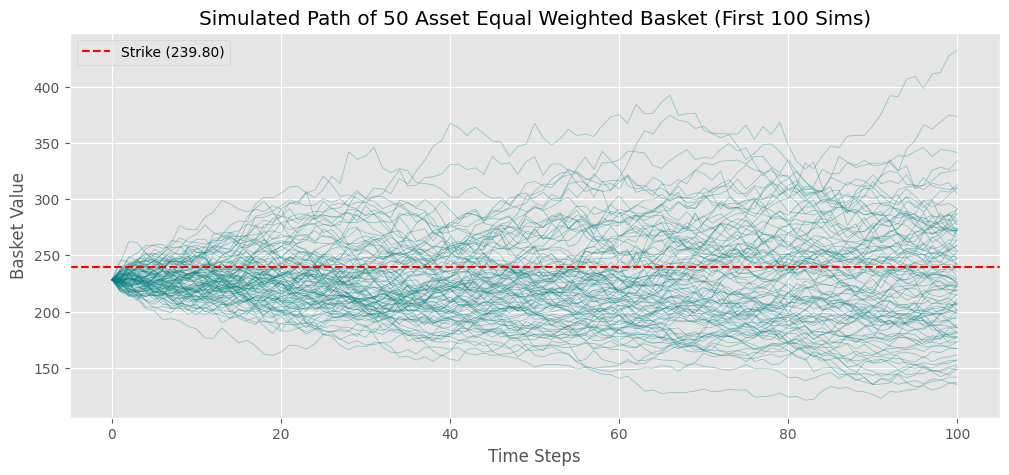

In [35]:
# Cell 6: Top 50 S&P 500 Basket Execution

top_50_tickers = [
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'META', 'GOOGL', 'GOOG', 'BRK-B', 'LLY', 'AVGO',
    'TSLA', 'JPM', 'UNH', 'V', 'XOM', 'MA', 'JNJ', 'PG', 'HD', 'COST',
    'MRK', 'ABBV', 'CRM', 'CVX', 'AMD', 'BAC', 'NFLX', 'PEP', 'KO', 'LIN',
    'WMT', 'TMO', 'MCD', 'DIS', 'ACN', 'CSCO', 'INTU', 'WFC', 'QCOM', 'AMGN',
    'IBM', 'TXN', 'NOW', 'GE', 'CAT', 'SPGI', 'BA', 'HON', 'AXP', 'UNP'
]

S0_real, sigmas_real, corr_real = MarketCalibrator.calibrate(top_50_tickers, '2020-01-01', '2024-01-01')

print(f"\n--- Market Calibration (Top 50) ---")
print(f"Average Volatility across basket: {np.mean(sigmas_real):.2%}")
print(f"Average Correlation across basket: {np.mean(corr_real - np.eye(50)):.4f}") # Excluded self-correlation

risk_free_rate = 0.04
time_to_maturity = 1.0
engine = UnifiedMonteCarloEngine(rate_data=ConstantRate(risk_free_rate), rng=AntitheticMultiRNG())

weights = np.ones(50) / 50.0
current_basket_value = np.dot(S0_real, weights)
basket_strike = current_basket_value * 1.05

basket_opt = BasketCall(strike=basket_strike, maturity=time_to_maturity, weights=weights)

print("\nStarting up the Numba Engine (Processing 100 Million data points)")
res_basket = engine.price(basket_opt, S0_real, sigmas_real, corr_real, n_sims=20000, n_steps=100)

print(f"Initial Basket Spot Price: {current_basket_value:.2f}")
print(f"Basket Strike Price: {basket_strike:.2f}")
print(f"Basket Call Price (20k sims): {res_basket['price']:.4f} +/- {1.96 * res_basket['std_err']:.4f}")

basket_paths = np.tensordot(res_basket['paths'], weights, axes=([1], [0])) # Shape: (sims, steps)

plt.figure(figsize=(12, 5))
plt.plot(basket_paths[:100, :].T, lw=0.5, alpha=0.4, color='teal')
plt.axhline(y=basket_strike, color='red', linestyle='--', label=f'Strike ({basket_strike:.2f})')
plt.title("Simulated Path of 50 Asset Equal Weighted Basket (First 100 Sims)")
plt.xlabel("Time Steps")
plt.ylabel("Basket Value")
plt.legend()
plt.show()

Generating fixed random shocks for stable Greeks
Calculating partial derivatives (Central Difference)

--- Top 10 Delta Exposures (Shares to Hedge) ---
 INTU: 0.011745
  NOW: 0.011559
 AMZN: 0.011496
  LLY: 0.011330
  CVX: 0.011287
 AMGN: 0.011139
 CSCO: 0.011120
 GOOG: 0.011099
  TMO: 0.011068
BRK-B: 0.011008


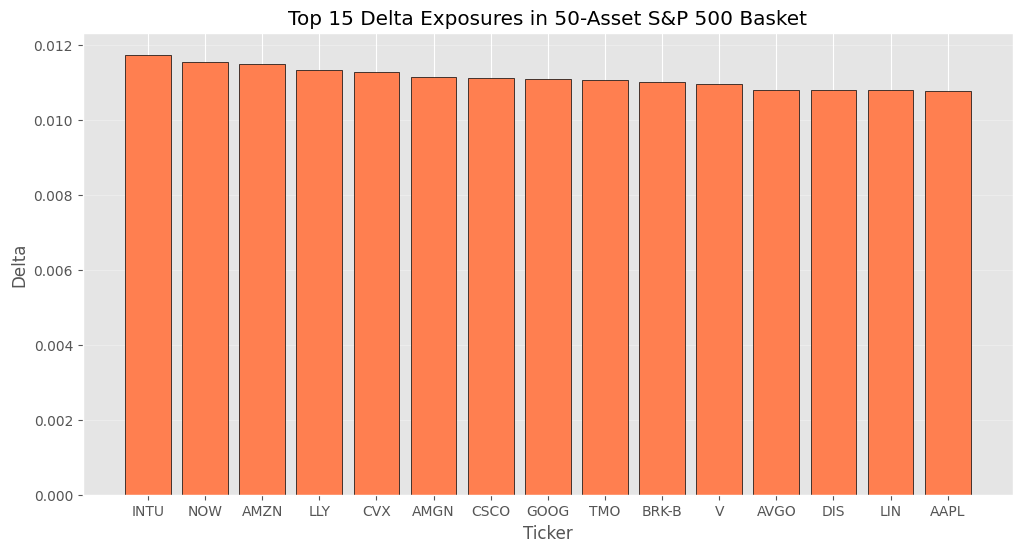

In [36]:
# Cell 7: Multi-Asset Delta Vector
def calculate_basket_deltas(engine: UnifiedMonteCarloEngine, instrument: Instrument,
                            S0: np.ndarray, sigmas: np.ndarray, corr_matrix: np.ndarray,
                            n_sims: int, n_steps: int, ds: float = 0.01) -> np.ndarray:
    n_assets = S0.shape[0]
    deltas = np.zeros(n_assets)

    # 1. Generate CRN (Common Random Numbers) ONCE
    print("Generating fixed random shocks for stable Greeks")
    z_fixed = engine.rng.generate(n_sims, n_assets, n_steps)

    # 2. Iterate through each asset to calculate its specific Delta
    print("Calculating partial derivatives (Central Difference)")
    for i in range(n_assets):
        # Bump UP
        S0_up = S0.copy()
        S0_up[i] += ds
        p_up = engine.price(instrument, S0_up, sigmas, corr_matrix, n_sims, n_steps, z_fixed=z_fixed)["price"]

        # Bump DOWN
        S0_down = S0.copy()
        S0_down[i] -= ds
        p_down = engine.price(instrument, S0_down, sigmas, corr_matrix, n_sims, n_steps, z_fixed=z_fixed)["price"]

        # Central Difference
        deltas[i] = (p_up - p_down) / (2 * ds)

    return deltas

# --- Execution ---
# We use 20,000 sims again. This will require 100 separate pricing runs.
# Because of Numba, this should only take a few seconds on a basic cpu.
basket_deltas = calculate_basket_deltas(engine, basket_opt, S0_real, sigmas_real, corr_real, n_sims=20000, n_steps=100)

# Combine tickers with their respective Deltas
delta_report = list(zip(top_50_tickers, basket_deltas))
# Sort by absolute risk exposure
delta_report.sort(key=lambda x: abs(x[1]), reverse=True)

print("\n--- Top 10 Delta Exposures (Shares to Hedge) ---")
for ticker, delta in delta_report[:10]:
    print(f"{ticker:>5}: {delta:.6f}")

# Visualization: Risk Bar Chart
top_tickers = [x[0] for x in delta_report[:15]]
top_exposures = [x[1] for x in delta_report[:15]]

plt.figure(figsize=(12, 6))
plt.bar(top_tickers, top_exposures, color='coral', edgecolor='black')
plt.title("Top 15 Delta Exposures in 50-Asset S&P 500 Basket")
plt.ylabel("Delta")
plt.xlabel("Ticker")
plt.grid(axis='y', alpha=0.3)
plt.show()

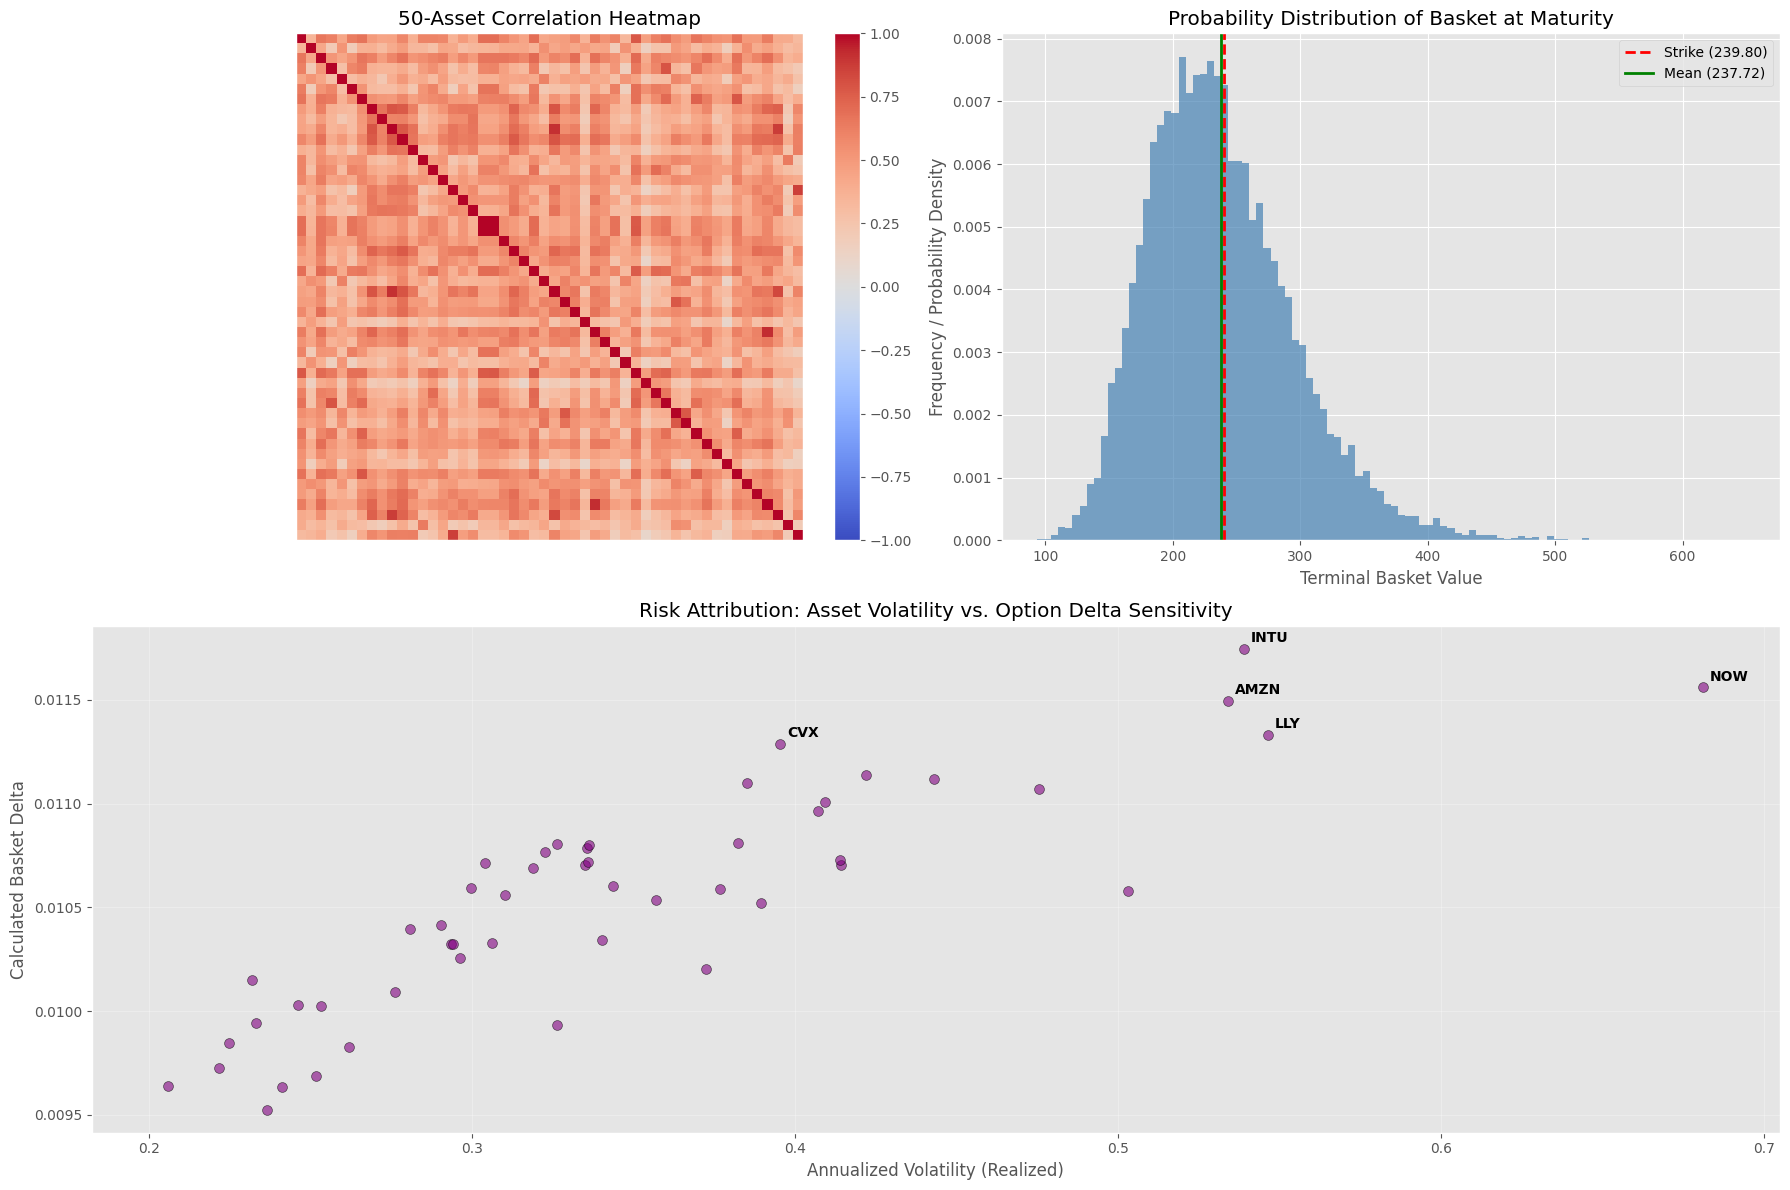

Probability of Basket Expiring In-The-Money (ITM): 43.41%


In [37]:
# Cell 8: The Quant Desk Dashboard
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(18, 12))

# --- 1. Correlation Matrix Heatmap ---
# Why: Shows you the clustering of your assets. Are they all moving together?
ax1 = fig.add_subplot(2, 2, 1)
cax = ax1.imshow(corr_real, cmap='coolwarm', vmin=-1, vmax=1)
ax1.set_title("50-Asset Correlation Heatmap")
fig.colorbar(cax, ax=ax1, fraction=0.046, pad=0.04)
# Hide ticks for a cleaner look on large matrices
ax1.set_xticks([])
ax1.set_yticks([])

# --- 2. Terminal PnL Distribution (Histogram) ---
# Why: Shows the actual probability density of where the basket will end up at maturity.
ax2 = fig.add_subplot(2, 2, 2)
terminal_values = basket_paths[:, -1] # Grab the last column of our simulated paths
ax2.hist(terminal_values, bins=100, color='steelblue', alpha=0.7, density=True)
ax2.axvline(basket_strike, color='red', linestyle='--', linewidth=2, label=f'Strike ({basket_strike:.2f})')
ax2.axvline(np.mean(terminal_values), color='green', linestyle='-', linewidth=2, label=f'Mean ({np.mean(terminal_values):.2f})')
ax2.set_title("Probability Distribution of Basket at Maturity")
ax2.set_xlabel("Terminal Basket Value")
ax2.set_ylabel("Frequency / Probability Density")
ax2.legend()

# --- 3. Risk Scatter Plot: Volatility vs. Delta ---
# Why: Since our basket is equally weighted, any difference in a stock's Delta
# is driven strictly by its volatility and its correlation to the rest of the basket.
ax3 = fig.add_subplot(2, 1, 2)
ax3.scatter(sigmas_real, basket_deltas, color='purple', alpha=0.6, edgecolors='black', s=50)

# Annotate the top 5 riskiest outliers
sorted_indices = np.argsort(basket_deltas)[::-1]
for i in sorted_indices[:5]:
    ax3.annotate(top_50_tickers[i],
                 (sigmas_real[i], basket_deltas[i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

ax3.set_title("Risk Attribution: Asset Volatility vs. Option Delta Sensitivity")
ax3.set_xlabel("Annualized Volatility (Realized)")
ax3.set_ylabel("Calculated Basket Delta")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate ITM Probability
itm_probability = np.sum(terminal_values > basket_strike) / len(terminal_values)
print(f"Probability of Basket Expiring In-The-Money (ITM): {itm_probability:.2%}")